# 01 · Build the YOLOv8 dataset

**Phase 0 + 1** of the pipeline.

Converts the Pascal VOC XML annotations that ship with PKU-Market-PCB into
YOLO `.txt` labels, and organises everything into `train` / `val` / `test`
folders with a `data.yaml`.

**Input**  `data/raw/Annotations/<Class>/*.xml` and `data/raw/images/<Class>/*.jpg`
**Output** `data/yolo/images/{train,val,test}`, `data/yolo/labels/{train,val,test}`, `data/yolo/data.yaml`

Run this once. Everything downstream depends on it.

## 1 · Setup

In [1]:
# ---------------------------------------------------------------------
# Locate the project root.
#
# This notebook may sit in notebook/, or in notebook/<yourname>/, so the
# search walks upwards until it finds the folder containing "data".
# Every path below is built from PROJECT_ROOT, so nothing breaks when the
# notebook is moved or when a teammate runs it on a different machine.
# ---------------------------------------------------------------------
from pathlib import Path

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "data").is_dir() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / "data").is_dir():
    raise SystemExit(
        "Could not find the project root (a folder containing 'data').\n"
        "Set PROJECT_ROOT manually, for example:\n"
        "    PROJECT_ROOT = Path(r'C:/Users/you/PCB-Defect-Inspection')")

RAW_DIR       = PROJECT_ROOT / "data" / "raw"        # Annotations + images
YOLO_DIR      = PROJECT_ROOT / "data" / "yolo"       # generated in notebook 01
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"  # generated in notebook 02
RUNS_DIR      = PROJECT_ROOT / "runs" / "pcb_comparison"

print("Project root :", PROJECT_ROOT)
print("Raw data     :", RAW_DIR, "  exists:", RAW_DIR.is_dir())

Project root : e:\SCHOOL\DEGY3S1\Image Processing\PCB-Defect-Inspection
Raw data     : e:\SCHOOL\DEGY3S1\Image Processing\PCB-Defect-Inspection\data\raw   exists: True


In [2]:
import shutil
import xml.etree.ElementTree as ET
from collections import Counter, defaultdict

# ---------------------------------------------------------------------
# The order of this list defines the YOLO class index: missing_hole is 0,
# mouse_bite is 1, and so on. It must match data.yaml exactly, and must
# never be reordered once any label file has been written.
# ---------------------------------------------------------------------
CLASS_NAMES = [
    "missing_hole",
    "mouse_bite",
    "open_circuit",
    "short",
    "spur",
    "spurious_copper",
]
CLASS_TO_ID = {name: i for i, name in enumerate(CLASS_NAMES)}

# ---------------------------------------------------------------------
# The split is by BOARD ID, not by individual image.
#
# Every defect image is a synthetic modification of one of ten physical
# boards. Splitting at random would put modified copies of the same board
# into both training and test sets, and the model could then score well by
# recognising the board rather than the defect. That would make the test
# result meaningless.
# ---------------------------------------------------------------------
SPLITS = {
    "train": ["01", "05", "06", "07", "08", "09", "11"],
    "val":   ["12"],
    "test":  ["04", "10"],
}

COPY_IMAGES = False   # False = symlink (fast, saves ~1 GB)
                      # True  = real copies (needed on Windows without
                      #         Developer Mode, or to move the dataset)

for split, boards in SPLITS.items():
    print(f"{split:<6} {', '.join(boards)}")

train  01, 05, 06, 07, 08, 09, 11
val    12
test   04, 10


## 2 · The conversion

VOC stores absolute pixel corners. YOLO wants the box centre and size, each
divided by the image dimensions so every value falls between 0 and 1:

```
x_center = (xmin + xmax) / 2 / image_width
y_center = (ymin + ymax) / 2 / image_height
width    = (xmax - xmin)     / image_width
height   = (ymax - ymin)     / image_height
```

In [3]:
def convert_boxes(xml_path):
    """Read one VOC XML file and return YOLO label lines plus any warnings."""
    root = ET.parse(xml_path).getroot()

    image_width = int(root.findtext("size/width"))
    image_height = int(root.findtext("size/height"))

    lines, warnings = [], []

    if image_width <= 0 or image_height <= 0:
        return [], [f"{xml_path.name}: bad image size in XML"]

    for obj in root.findall("object"):
        raw_name = obj.findtext("name").strip().lower()

        if raw_name not in CLASS_TO_ID:
            warnings.append(f"{xml_path.name}: unknown class '{raw_name}'")
            continue

        box = obj.find("bndbox")
        # float() first, because some VOC files store decimal coordinates.
        xmin = float(box.findtext("xmin"))
        ymin = float(box.findtext("ymin"))
        xmax = float(box.findtext("xmax"))
        ymax = float(box.findtext("ymax"))

        # Guard against corners stored in the wrong order.
        if xmax < xmin:
            xmin, xmax = xmax, xmin
        if ymax < ymin:
            ymin, ymax = ymax, ymin

        # Clip to the image, in case a box runs slightly past the edge.
        xmin, xmax = max(xmin, 0), min(xmax, image_width)
        ymin, ymax = max(ymin, 0), min(ymax, image_height)

        if xmax <= xmin or ymax <= ymin:
            warnings.append(f"{xml_path.name}: empty box after clipping")
            continue

        x_center = (xmin + xmax) / 2 / image_width
        y_center = (ymin + ymax) / 2 / image_height
        width = (xmax - xmin) / image_width
        height = (ymax - ymin) / image_height

        lines.append(f"{CLASS_TO_ID[raw_name]} "
                     f"{x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}")

    return lines, warnings


def board_id(filename):
    """Extract the board number from a name such as '01_missing_hole_01'."""
    return filename.split("_")[0]


print("Conversion functions defined.")

Conversion functions defined.


## 3 · Build the dataset

In [4]:
annotations_dir = RAW_DIR / "Annotations"
images_dir = RAW_DIR / "images"

if not annotations_dir.is_dir() or not images_dir.is_dir():
    raise SystemExit(f"Expected 'Annotations' and 'images' inside {RAW_DIR}")

# Map each board ID to the split it belongs to.
split_of_board = {board: split
                  for split, boards in SPLITS.items()
                  for board in boards}

# YOLO finds a label by taking the image path and replacing 'images' with
# 'labels', so the two folder trees must mirror each other exactly.
for split in SPLITS:
    (YOLO_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
    (YOLO_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)

xml_files = sorted(annotations_dir.glob("*/*.xml"))
print(f"Found {len(xml_files)} annotation files\n")

counts, objects = defaultdict(int), defaultdict(int)
per_class = defaultdict(Counter)
unassigned, missing_images, empty_labels, warnings = [], [], [], []

for xml_path in xml_files:
    stem = xml_path.stem
    split = split_of_board.get(board_id(stem))

    if split is None:
        unassigned.append(stem)
        continue

    image_path = images_dir / xml_path.parent.name / f"{stem}.jpg"
    if not image_path.exists():
        missing_images.append(stem)
        continue

    label_lines, file_warnings = convert_boxes(xml_path)
    warnings.extend(file_warnings)

    # Every image in this dataset contains defects, so an empty result means
    # the conversion failed rather than that the board is clean.
    if not label_lines:
        empty_labels.append(stem)
        continue

    (YOLO_DIR / "labels" / split / f"{stem}.txt").write_text(
        "\n".join(label_lines) + "\n")

    destination = YOLO_DIR / "images" / split / f"{stem}.jpg"
    if COPY_IMAGES:
        shutil.copy2(image_path, destination)
    else:
        if destination.exists() or destination.is_symlink():
            destination.unlink()
        try:
            destination.symlink_to(image_path.resolve())
        except OSError:
            # Windows refuses symlinks without Developer Mode or admin rights.
            shutil.copy2(image_path, destination)

    counts[split] += 1
    objects[split] += len(label_lines)
    for line in label_lines:
        per_class[split][CLASS_NAMES[int(line.split()[0])]] += 1

print("Conversion complete.")

Found 693 annotation files

Conversion complete.


## 4 · Write `data.yaml`

In [5]:
names_block = "\n".join(f"  {i}: {name}" for i, name in enumerate(CLASS_NAMES))

yaml_text = f"""# data.yaml - PCB defect detection (PKU-Market-PCB)
# Generated by 01_build_yolo_dataset.ipynb

path: {YOLO_DIR.resolve()}

train: images/train
val:   images/val
test:  images/test

nc: {len(CLASS_NAMES)}

# The order below defines the class index used in every label file.
# Do not reorder these once labels have been written.
names:
{names_block}
"""

(YOLO_DIR / "data.yaml").write_text(yaml_text)
print(yaml_text)

# data.yaml - PCB defect detection (PKU-Market-PCB)
# Generated by 01_build_yolo_dataset.ipynb

path: E:\SCHOOL\DEGY3S1\Image Processing\PCB-Defect-Inspection\data\yolo

train: images/train
val:   images/val
test:  images/test

nc: 6

# The order below defines the class index used in every label file.
# Do not reorder these once labels have been written.
names:
  0: missing_hole
  1: mouse_bite
  2: open_circuit
  3: short
  4: spur
  5: spurious_copper



## 5 · Verify

Nothing downstream is worth running if this section reports a problem, so
check it before moving on.

In [6]:
total_images = sum(counts.values())
total_objects = sum(objects.values())

print(f"{'split':<8}{'images':>8}{'boxes':>8}{'share':>8}   boards")
for split, boards in SPLITS.items():
    share = 100 * counts[split] / total_images if total_images else 0
    print(f"{split:<8}{counts[split]:>8}{objects[split]:>8}"
          f"{share:>7.1f}%   {', '.join(boards)}")
print(f"{'TOTAL':<8}{total_images:>8}{total_objects:>8}")

print("\nBoxes per class:")
print(f"{'class':<18}" + "".join(f"{s:>8}" for s in SPLITS))
for name in CLASS_NAMES:
    print(f"{name:<18}" + "".join(f"{per_class[s][name]:>8}" for s in SPLITS))

for label, items in [("images with no split", unassigned),
                     ("annotations with no image", missing_images),
                     ("images that produced no labels", empty_labels)]:
    if items:
        print(f"\nWARNING - {label}: {len(items)}")
        print("   " + ", ".join(items[:10]))

if warnings:
    print(f"\nWARNING - {len(warnings)} box-level issue(s)")
    for message in warnings[:10]:
        print("   " + message)

if not (unassigned or missing_images or empty_labels or warnings):
    print("\nNo problems found.")

split     images   boxes   share   boards
train        481    2130   69.4%   01, 05, 06, 07, 08, 09, 11
val           60     303    8.7%   12
test         152     520   21.9%   04, 10
TOTAL        693    2953

Boxes per class:
class                train     val    test
missing_hole           360      52      85
mouse_bite             356      50      86
open_circuit           343      50      89
short                  357      50      84
spur                   352      51      85
spurious_copper        362      50      91

No problems found.


In [7]:
# ---------------------------------------------------------------------
# Round-trip check: convert the YOLO labels back to pixel corners and
# compare against the original XML. This is the check that proves the
# normalisation is correct rather than merely plausible.
# ---------------------------------------------------------------------
worst_error, checked, mismatches = 0.0, 0, []

for label_path in sorted(YOLO_DIR.glob("labels/*/*.txt")):
    matches = list(annotations_dir.glob(f"*/{label_path.stem}.xml"))
    if len(matches) != 1:
        mismatches.append(f"{label_path.stem}: {len(matches)} XML matches")
        continue

    root = ET.parse(matches[0]).getroot()
    W = int(root.findtext("size/width"))
    H = int(root.findtext("size/height"))

    source = [(o.findtext("name").strip().lower(),
               float(o.find("bndbox").findtext("xmin")),
               float(o.find("bndbox").findtext("ymin")),
               float(o.find("bndbox").findtext("xmax")),
               float(o.find("bndbox").findtext("ymax")))
              for o in root.findall("object")]

    rows = [r.split() for r in label_path.read_text().split("\n") if r.strip()]
    if len(rows) != len(source):
        mismatches.append(f"{label_path.stem}: box count differs")
        continue

    for (name, x1, y1, x2, y2), row in zip(source, rows):
        if CLASS_NAMES[int(row[0])] != name:
            mismatches.append(f"{label_path.stem}: class mismatch")
        xc, yc, w, h = map(float, row[1:])
        error = max(abs((xc - w / 2) * W - x1), abs((xc + w / 2) * W - x2),
                    abs((yc - h / 2) * H - y1), abs((yc + h / 2) * H - y2))
        worst_error = max(worst_error, error)
        checked += 1

print(f"boxes round-tripped : {checked}")
print(f"worst corner error  : {worst_error:.4f} px   (float rounding only)")
print(f"mismatches          : {len(mismatches)}")
for m in mismatches[:5]:
    print("   ", m)

boxes round-tripped : 2953
worst corner error  : 0.0023 px   (float rounding only)
mismatches          : 0


In [8]:
# ---------------------------------------------------------------------
# Leakage check. No board may appear in more than one split.
# ---------------------------------------------------------------------
appears_in = defaultdict(set)
for path in YOLO_DIR.glob("images/*/*.jpg"):
    appears_in[board_id(path.stem)].add(path.parent.name)

leak = False
for board in sorted(appears_in):
    splits = sorted(appears_in[board])
    if len(splits) > 1:
        leak = True
    print(f"  board {board}: {splits}")

print("\nLEAKAGE DETECTED" if leak else
      "\nNo board appears in more than one split.")

for split in SPLITS:
    images = {p.stem for p in (YOLO_DIR / "images" / split).glob("*.jpg")}
    labels = {p.stem for p in (YOLO_DIR / "labels" / split).glob("*.txt")}
    print(f"  {split:<6} images={len(images)} labels={len(labels)} "
          f"unmatched={len(images ^ labels)}")

# ---------------------------------------------------------------------
# Dangling symlink check.
#
# With COPY_IMAGES = False the images are symlinks into data/raw. If that
# folder is later moved, renamed or deleted, every link breaks. YOLO then
# reports "No labels found", which gives no hint of the real cause, and it
# does so only once training starts. Catching it here saves that hunt.
# ---------------------------------------------------------------------
broken = [p for p in YOLO_DIR.glob("images/*/*.jpg") if not p.resolve().exists()]

if broken:
    print(f"\n*** {len(broken)} BROKEN IMAGE LINK(S) ***")
    print("The images point at files that no longer exist:")
    for p in broken[:5]:
        print(f"   {p.name} -> {p.resolve()}")
    print("\nFix: set COPY_IMAGES = True in section 1 and re-run this "
          "notebook, or restore data/raw to its original location.")
else:
    print(f"\nAll {len(list(YOLO_DIR.glob('images/*/*.jpg')))} image files "
          f"resolve correctly.")

  board 01: ['train']
  board 04: ['test']
  board 05: ['train']
  board 06: ['train']
  board 07: ['train']
  board 08: ['train']
  board 09: ['train']
  board 10: ['test']
  board 11: ['train']
  board 12: ['val']

No board appears in more than one split.
  train  images=481 labels=481 unmatched=0
  val    images=60 labels=60 unmatched=0
  test   images=152 labels=152 unmatched=0

All 693 image files resolve correctly.


## 6 · Look at the labels

The strongest check is visual: draw the converted boxes back onto the images
and confirm they land on real defects.

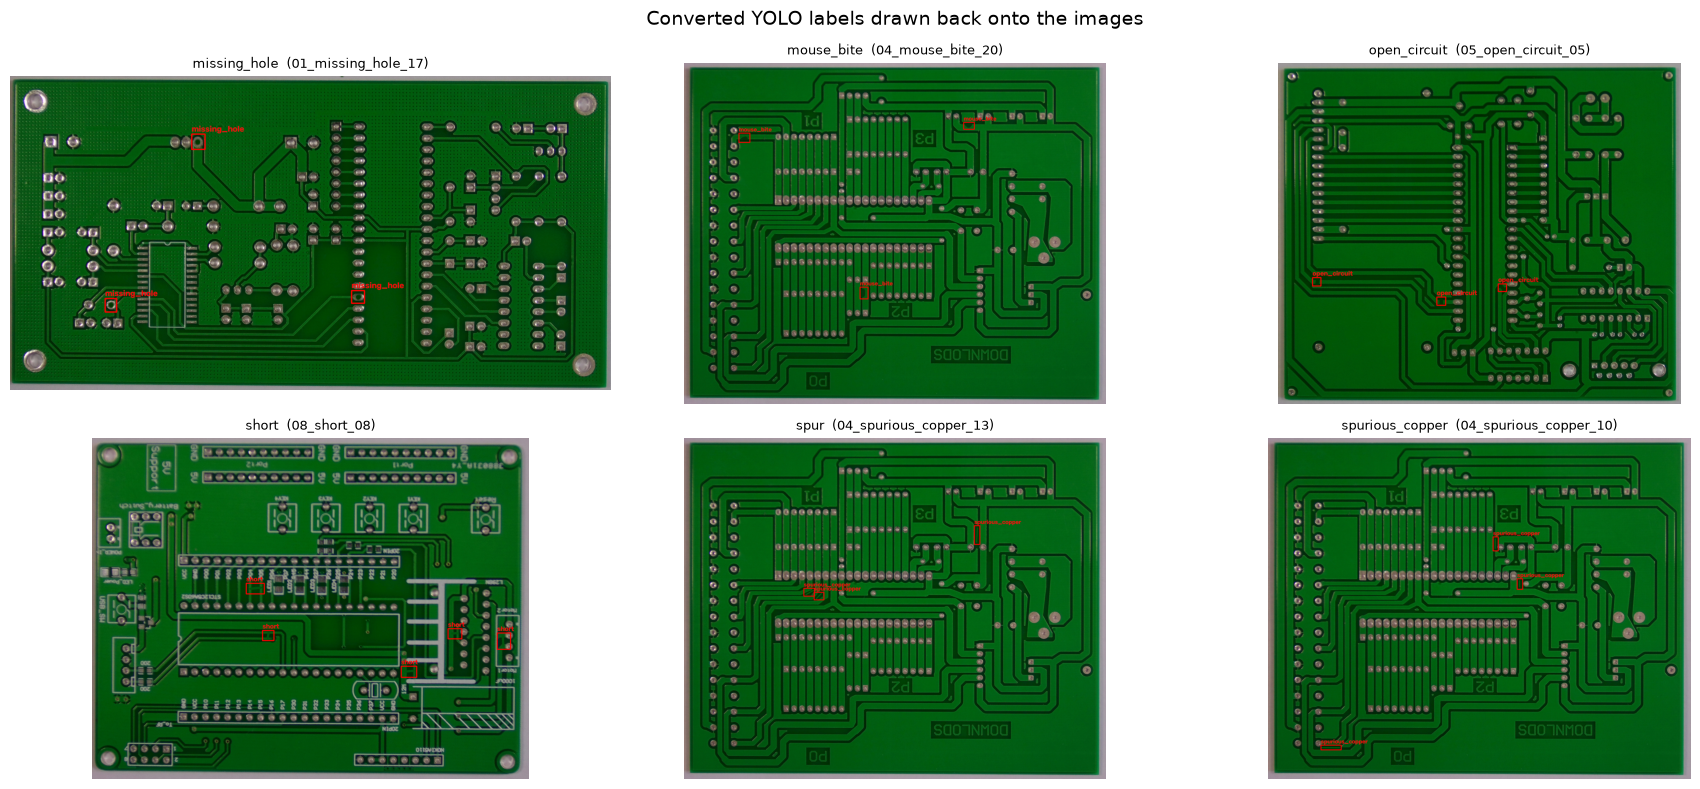

In [9]:
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt

random.seed(7)

fig, axes = plt.subplots(2, 3, figsize=(18, 8))

for ax, class_name in zip(axes.ravel(), CLASS_NAMES):
    candidates = [p for p in YOLO_DIR.glob("images/*/*.jpg")
                  if class_name in p.stem]
    if not candidates:
        ax.axis("off")
        continue

    image_path = random.choice(candidates)
    image = cv2.imread(str(image_path))
    H, W = image.shape[:2]

    label_path = Path(str(image_path).replace("images", "labels")).with_suffix(".txt")
    for row in [r for r in label_path.read_text().split("\n") if r.strip()]:
        cid, xc, yc, w, h = row.split()
        xc, yc, w, h = float(xc) * W, float(yc) * H, float(w) * W, float(h) * H
        p1 = (int(xc - w / 2), int(yc - h / 2))
        p2 = (int(xc + w / 2), int(yc + h / 2))
        cv2.rectangle(image, p1, p2, (0, 0, 255), 6)
        cv2.putText(image, CLASS_NAMES[int(cid)], (p1[0], max(p1[1] - 12, 24)),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.4, (255, 255, 255), 7)
        cv2.putText(image, CLASS_NAMES[int(cid)], (p1[0], max(p1[1] - 12, 24)),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.4, (0, 0, 255), 3)

    ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{class_name}  ({image_path.stem})", fontsize=9)
    ax.axis("off")

plt.suptitle("Converted YOLO labels drawn back onto the images", fontsize=14)
plt.tight_layout()
plt.show()

---

**Next:** `02_processed_dataset.ipynb` builds the nine processed datasets.

Before that, train the baseline on this unprocessed dataset — it is the number
every processed variant is compared against, and running it now proves the
whole pipeline works while only one thing can be wrong.